In [6]:
import warnings
import numpy as np
from pathlib import Path
from sunbird.inference.samples import Chain
from acm.utils.modules import get_class_from_module
from secondgen_bgs import get_secondgen_data

# getdist dark magic: Run this cell twice for plots to show up correctly
import matplotlib.pyplot as plt
%matplotlib inline
plt.show()

%config InlineBackend.figure_format='retina'

chain_dir = '/pscratch/sd/s/sbouchar/acm/bgs-20/chains/'

colors = ["#5ac3be", "#e770a2", "#4165c0", "#696969", "#f79a1e", "#ba7dcd"]

cosmo_params = ['omega_cdm', 'omega_b', 'sigma8_m', 'n_s', 'nrun', 'N_ur', 'w0_fld', 'wa_fld']
hod_params = ['logM_cut', 'logM_1', 'alpha', 'kappa', 'sigma', 'alpha_c', 'alpha_s', 's', 'A_cen', 'A_sat', 'B_cen', 'B_sat']

label_dict = {
    'tpcf': '2PCF', 
    'ds_xiqq+ds_xiqg': 'DS',
    'ds_xiqg+ds_xiqq': 'DS',
    'tpcf+ds_xiqq+ds_xiqg': '2PCF + DS',
    'tpcf+ds_xiqg+ds_xiqq': '2PCF + DS',
}

In [7]:
def get_chain(
    type_fit: str, 
    cosmo_model: str, 
    hod_model: str, 
    stat_name: str, 
    identifier: str = None,
    chain_dir: Path|str = chain_dir
) -> Chain:
    """Load a chain from disk trough the Chain class."""
    fn = stat_name
    if identifier is not None:
        fn += f'_{identifier}'
    chain_dir = Path(chain_dir)
    fn = chain_dir / type_fit / f'cosmo-{cosmo_model}_hod-{hod_model}' / f'{fn}.npy'
    if not fn.exists():
        return None
    chain = Chain.load(fn)
    chain.data['label'] = stat_name
    return chain

def get_chains(
    type_fit: str, 
    cosmo_model: str, 
    hod_model: str, 
    stats: list[str] = ['tpcf', 'ds_xiqg+ds_xiqq', 'tpcf+ds_xiqg+ds_xiqq'],
    identifier: str = None,
    chain_dir: Path|str = chain_dir
) -> list[Chain]:
    """Get several chains corresponding to different statistics."""
    chains = []
    for stat in stats:
        chain = get_chain(type_fit, cosmo_model, hod_model, stat, identifier=identifier, chain_dir=chain_dir)
        if chain is not None:
            chains.append(chain)
    return chains

def plot_secondgen_model_vs_truth(
    chain: Chain, 
    module: str = 'acm.observables.bgs', 
    observable_name: str = 'tpcf',
    add_model_errors: bool = True,
    **kwargs,
) -> tuple[plt.Figure, plt.Axes, tuple]:
    """
    Use the plot_observable method from the BGS observables to plot 
    the secondgen data vs the model prediction at the bestfit point of the chain.
    
    Parameters
    ----------
    chain : Chain
        The chain from which to get the bestfit parameters.
    module : str, optional
        The module where the observable class is located, by default 'acm.observables.bgs'
    observable_name : str, optional
        The name of the observable class to use the plot function from, by default 'tpcf'.
    add_model_errors : bool, optional
        Whether to add model errors to the plot, by default True.
        
    Returns
    -------
    fig : plt.Figure
        The figure object containing the plot.
    ax : plt.Axes
        The axes object containing the plot.
    tuple :
        A tuple containing the observable instance and the predicted errors.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        obs = get_class_from_module(module, observable_name)()
        
        model_err = obs.get_emulator_error()
        mock_err = np.sqrt(np.diag(obs.get_covariance_matrix()))
        pred_err = np.sqrt(model_err**2 + mock_err**2)
        
        sg_obs = get_secondgen_data(obs, return_obs=True)
        obs._dataset = sg_obs[0]._dataset
        
        kwargs['volume_factor'] = 1.0 # Enforce no volume scaling for secondgen
        fig, ax = obs.plot_observable(chain.bestfit, show_legend=True, **kwargs)
    
    if add_model_errors and observable_name == 'tpcf':
        s = obs.s.values
        ells = kwargs.get('ells', [0, 2])
        for i, ell in enumerate(ells):
            y = obs.get_model_prediction(chain.bestfit).unstack().sel(ells=ell).values
            err = pred_err.unstack().sel(ells=ell).values
            ax[0].fill_between(s, (y - err)*s**2, (y + err)*s**2, alpha=0.2, color=f'C{i}', zorder=-1)
    elif add_model_errors and observable_name in ['ds_xiqq', 'ds_xiqg']:
        s = obs.s.values
        ell = kwargs.get('ell', 0)
        quantiles = kwargs.get('quantiles', [0, 1, 3, 4])
        for i, q in enumerate(quantiles):
            y = obs.get_model_prediction(chain.bestfit).sel(ells=ell, quantiles=q).values
            err = pred_err.sel(ells=ell, quantiles=q).values
            ax[0].fill_between(s, (y - err)*s**2, (y + err)*s**2, alpha=0.2, color=f'C{i}', zorder=-1)
    elif add_model_errors:
        print(f'Warning: add_model_errors not implemented for observable {observable_name}.')
            
    return fig, ax

## Validation plots (c000 hod061)

### Free HOD

In [ ]:
chains = get_chains(type_fit='validation/c000_hod061', cosmo_model='None', hod_model='base-AB-CB-VB-s', identifier='bestfit')

markers = chains[0].markers
chains[0].plot_triangle(*chains[1:], add_bestfit=True, colors=colors, filled=True, title_limit=1, label_dict=label_dict, markers=markers, params=cosmo_params);

### LCDM

Removed no burn in
Removed no burn in
Removed no burn in


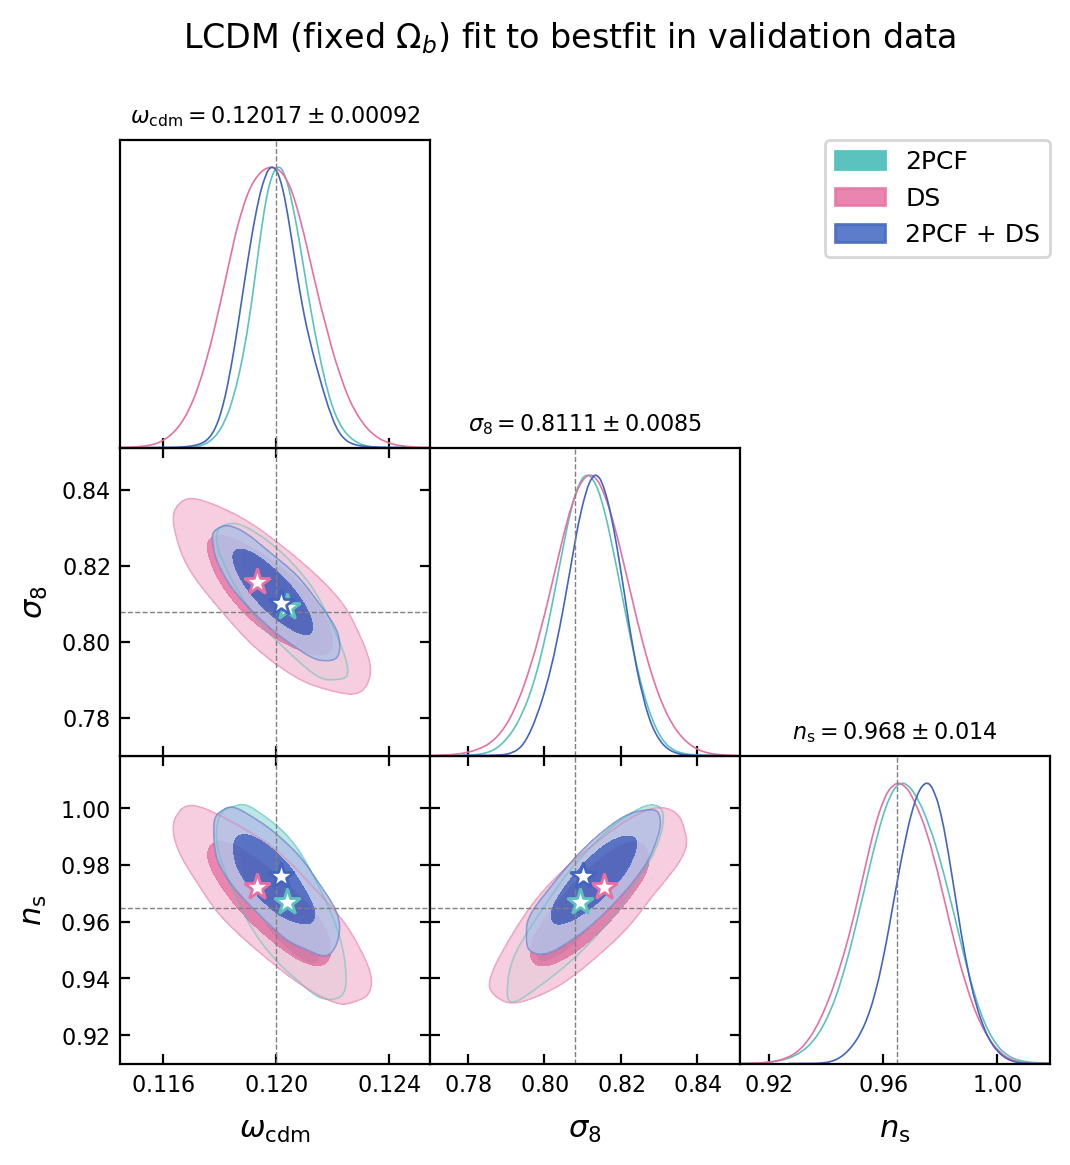

In [8]:
chains = get_chains(type_fit='validation/c000_hod061', cosmo_model='base-fixed-omega_b', hod_model='base-AB-CB-VB-s', identifier='bestfit')

markers = chains[0].markers
chains[0].plot_triangle(*chains[1:], add_bestfit=True, colors=colors, filled=True, title_limit=1, label_dict=label_dict, markers=markers, params=cosmo_params);

fig = plt.gcf()
fig.suptitle(r'LCDM (fixed $\Omega_b$) fit to bestfit in validation data');

### w0wa

Removed no burn in
Removed no burn in
Removed no burn in


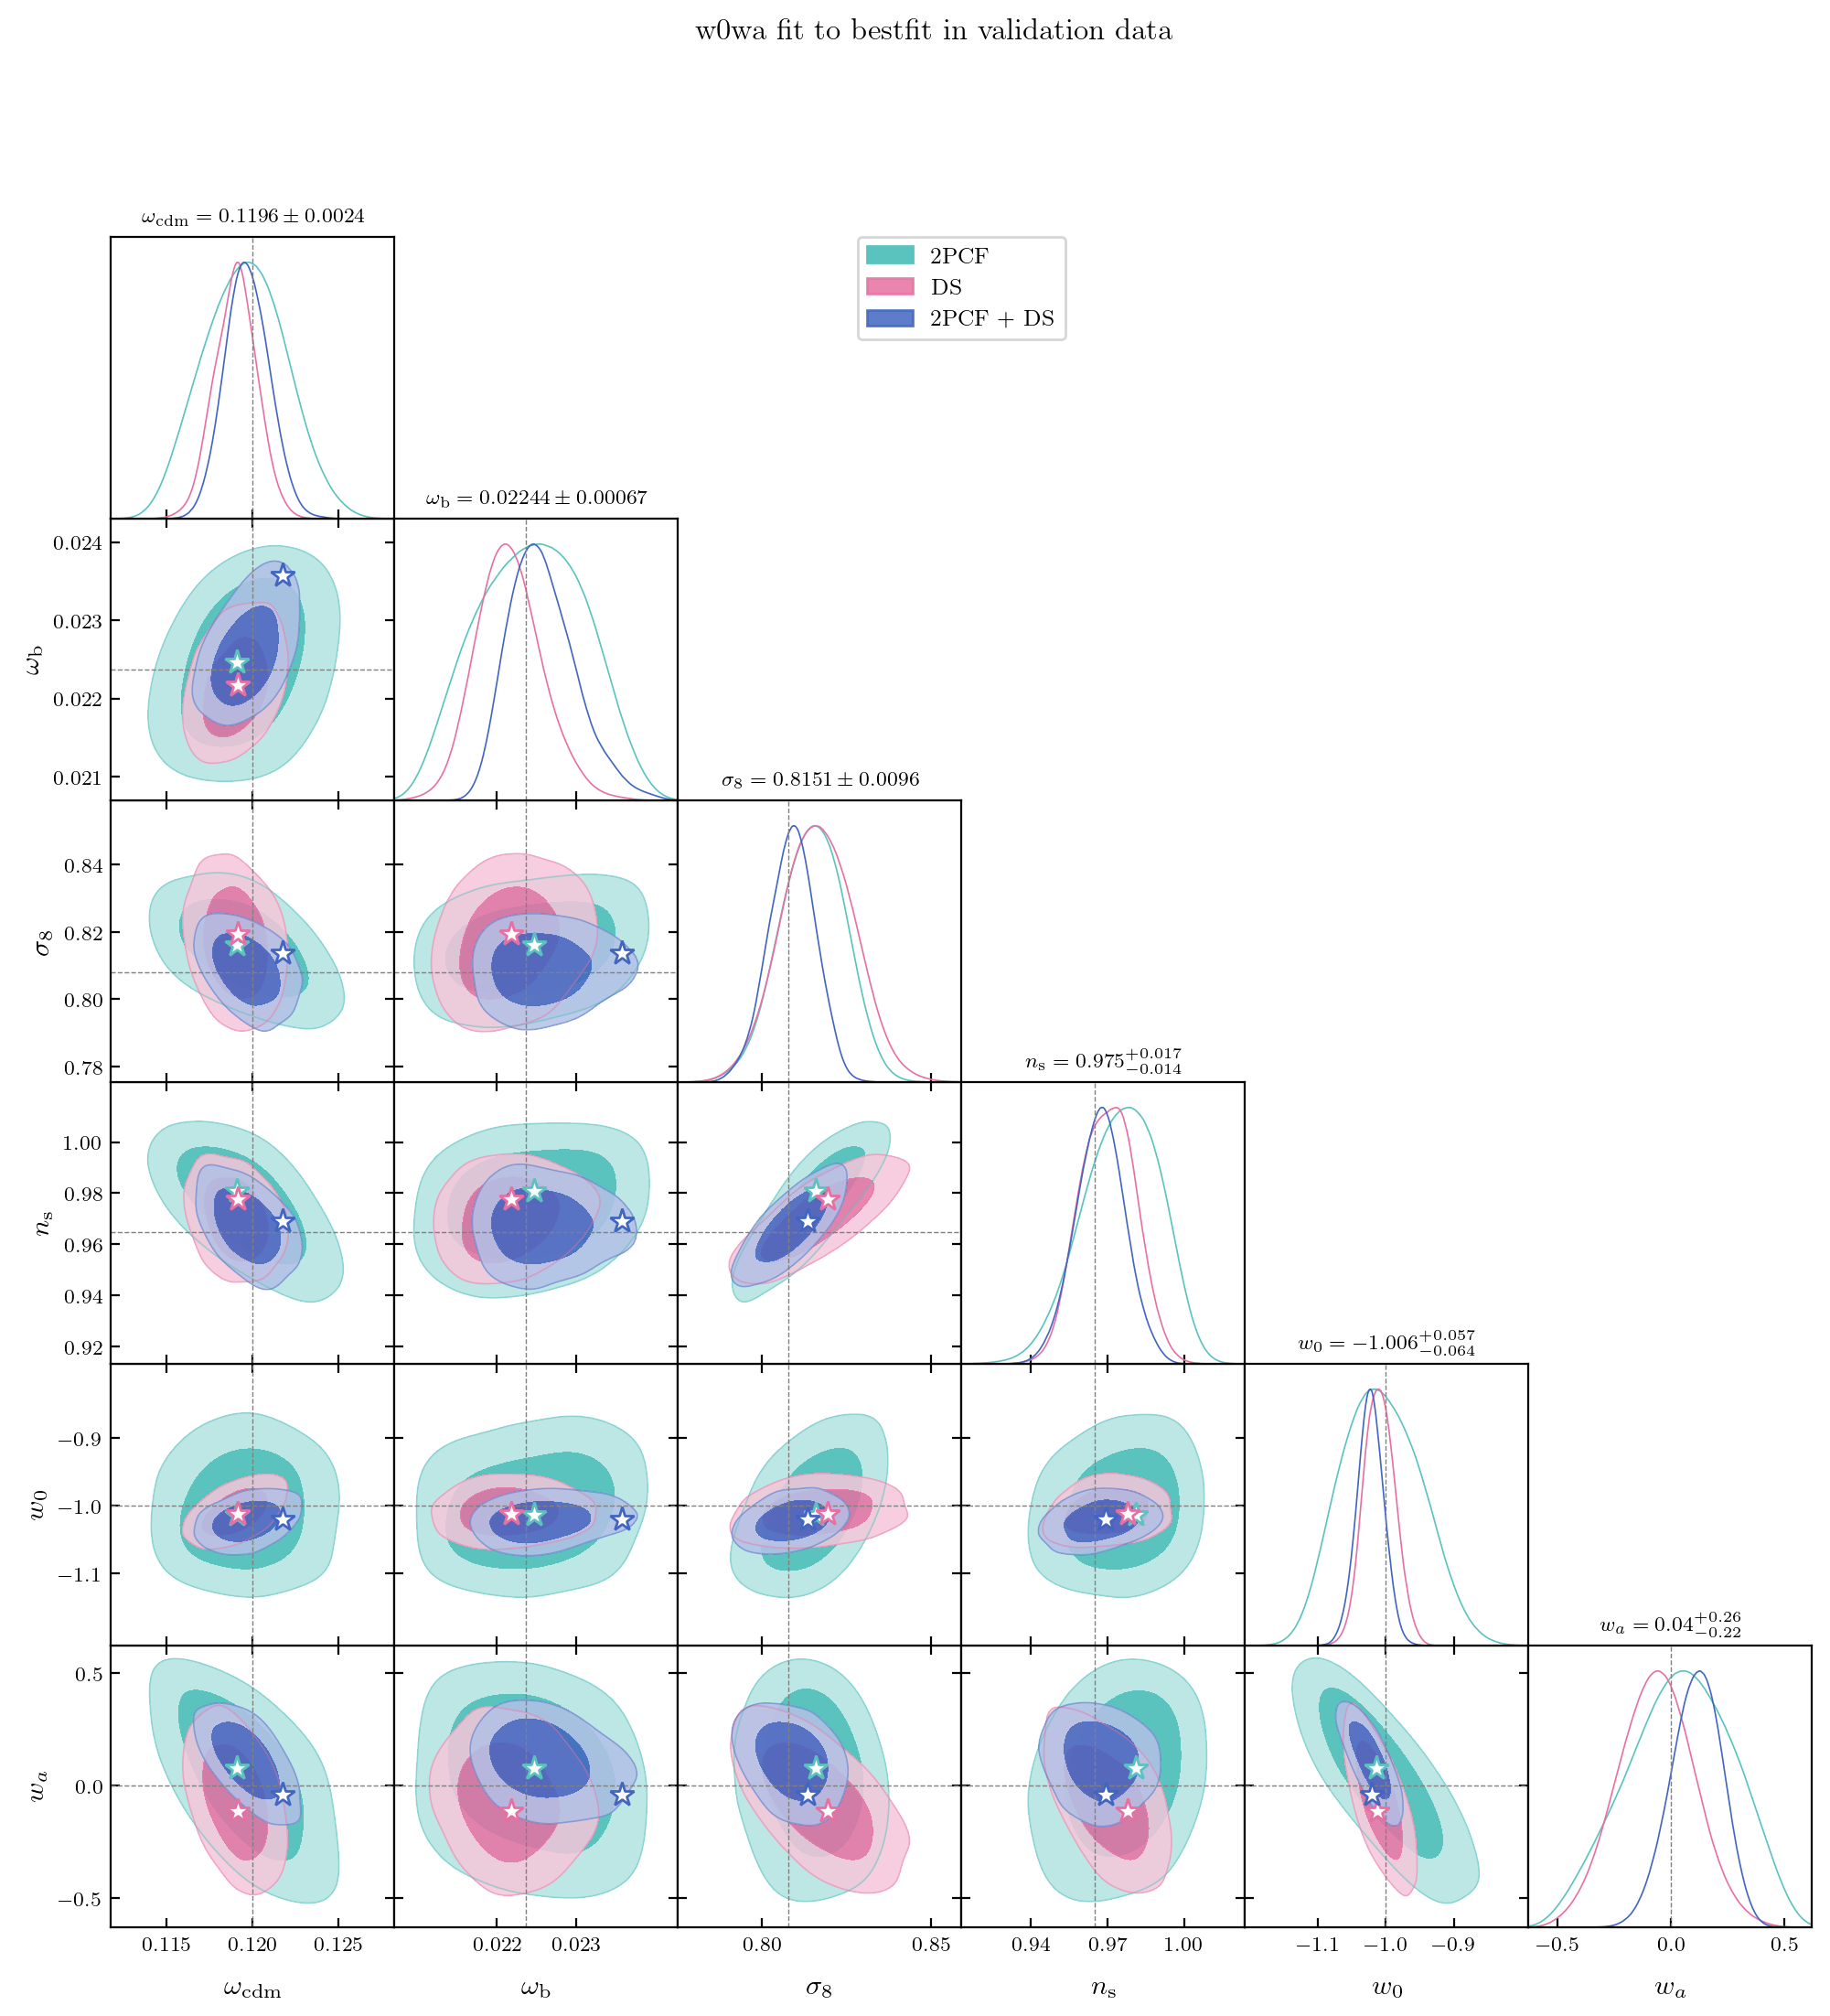

In [106]:
chains = get_chains(type_fit='validation/c000_hod061', cosmo_model='base-w0wa', hod_model='base-AB-CB-VB-s', identifier='bestfit')

markers = chains[0].markers
chains[0].plot_triangle(*chains[1:], add_bestfit=True, colors=colors, filled=True, title_limit=1, label_dict=label_dict, markers=markers, params=cosmo_params);

fig = plt.gcf()
fig.suptitle('w0wa fit to bestfit in validation data');

## SecondGen plots

### LCDM

Removed no burn in
Removed no burn in
Removed no burn in


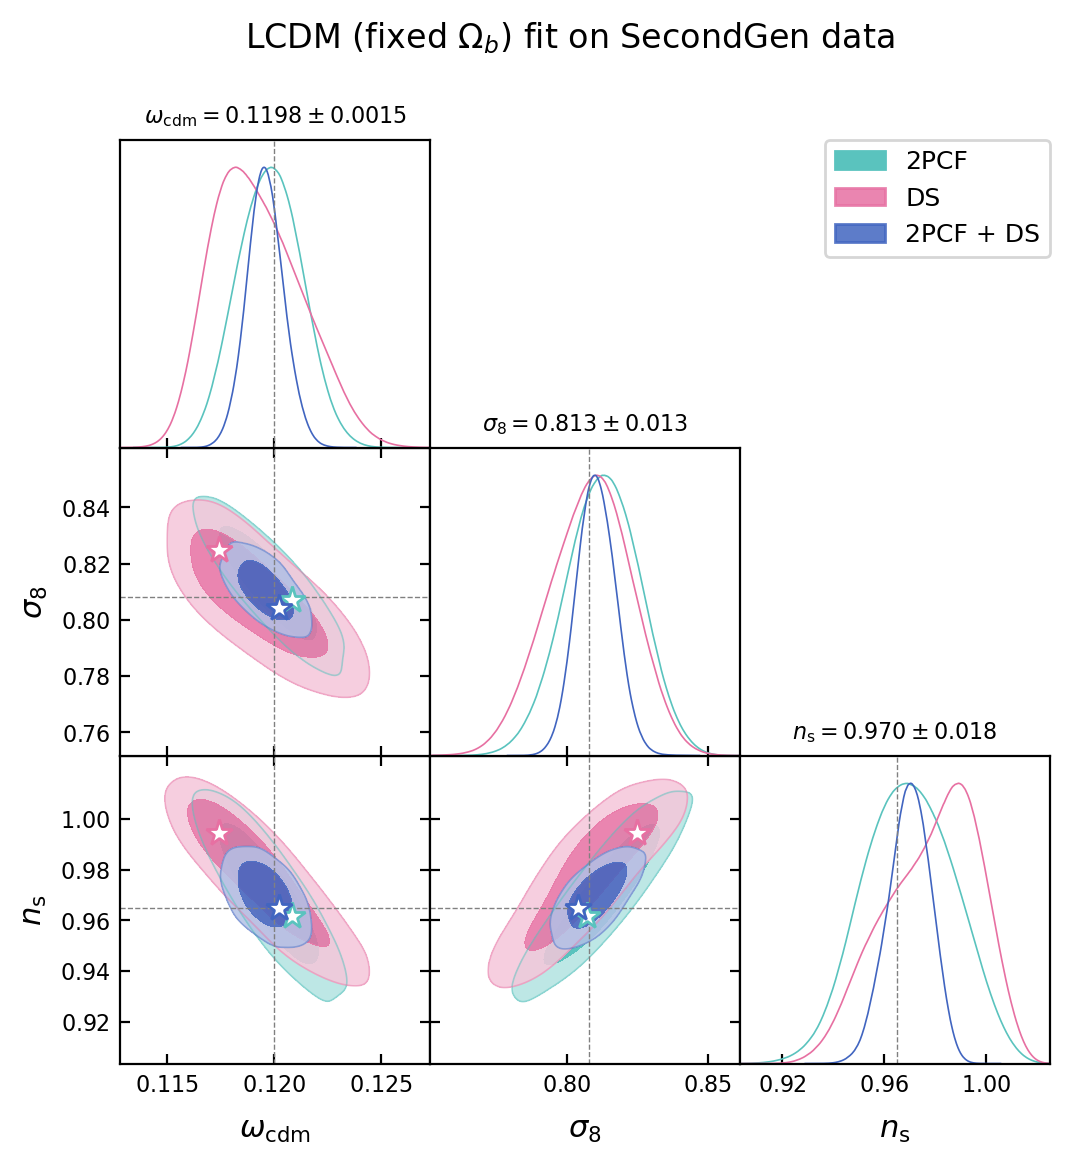

In [9]:
chains = get_chains(type_fit='secondgen', cosmo_model='base-fixed-omega_b', hod_model='base-AB-CB-VB-s')

markers = chains[0].markers
chains[0].plot_triangle(*chains[1:], add_bestfit=True, colors=colors, filled=True, title_limit=1, label_dict=label_dict, markers=markers, params=cosmo_params);

fig = plt.gcf()
fig.suptitle(r'LCDM (fixed $\Omega_b$) fit on SecondGen data');

### w0wa

Removed no burn in
Removed no burn in
Removed no burn in


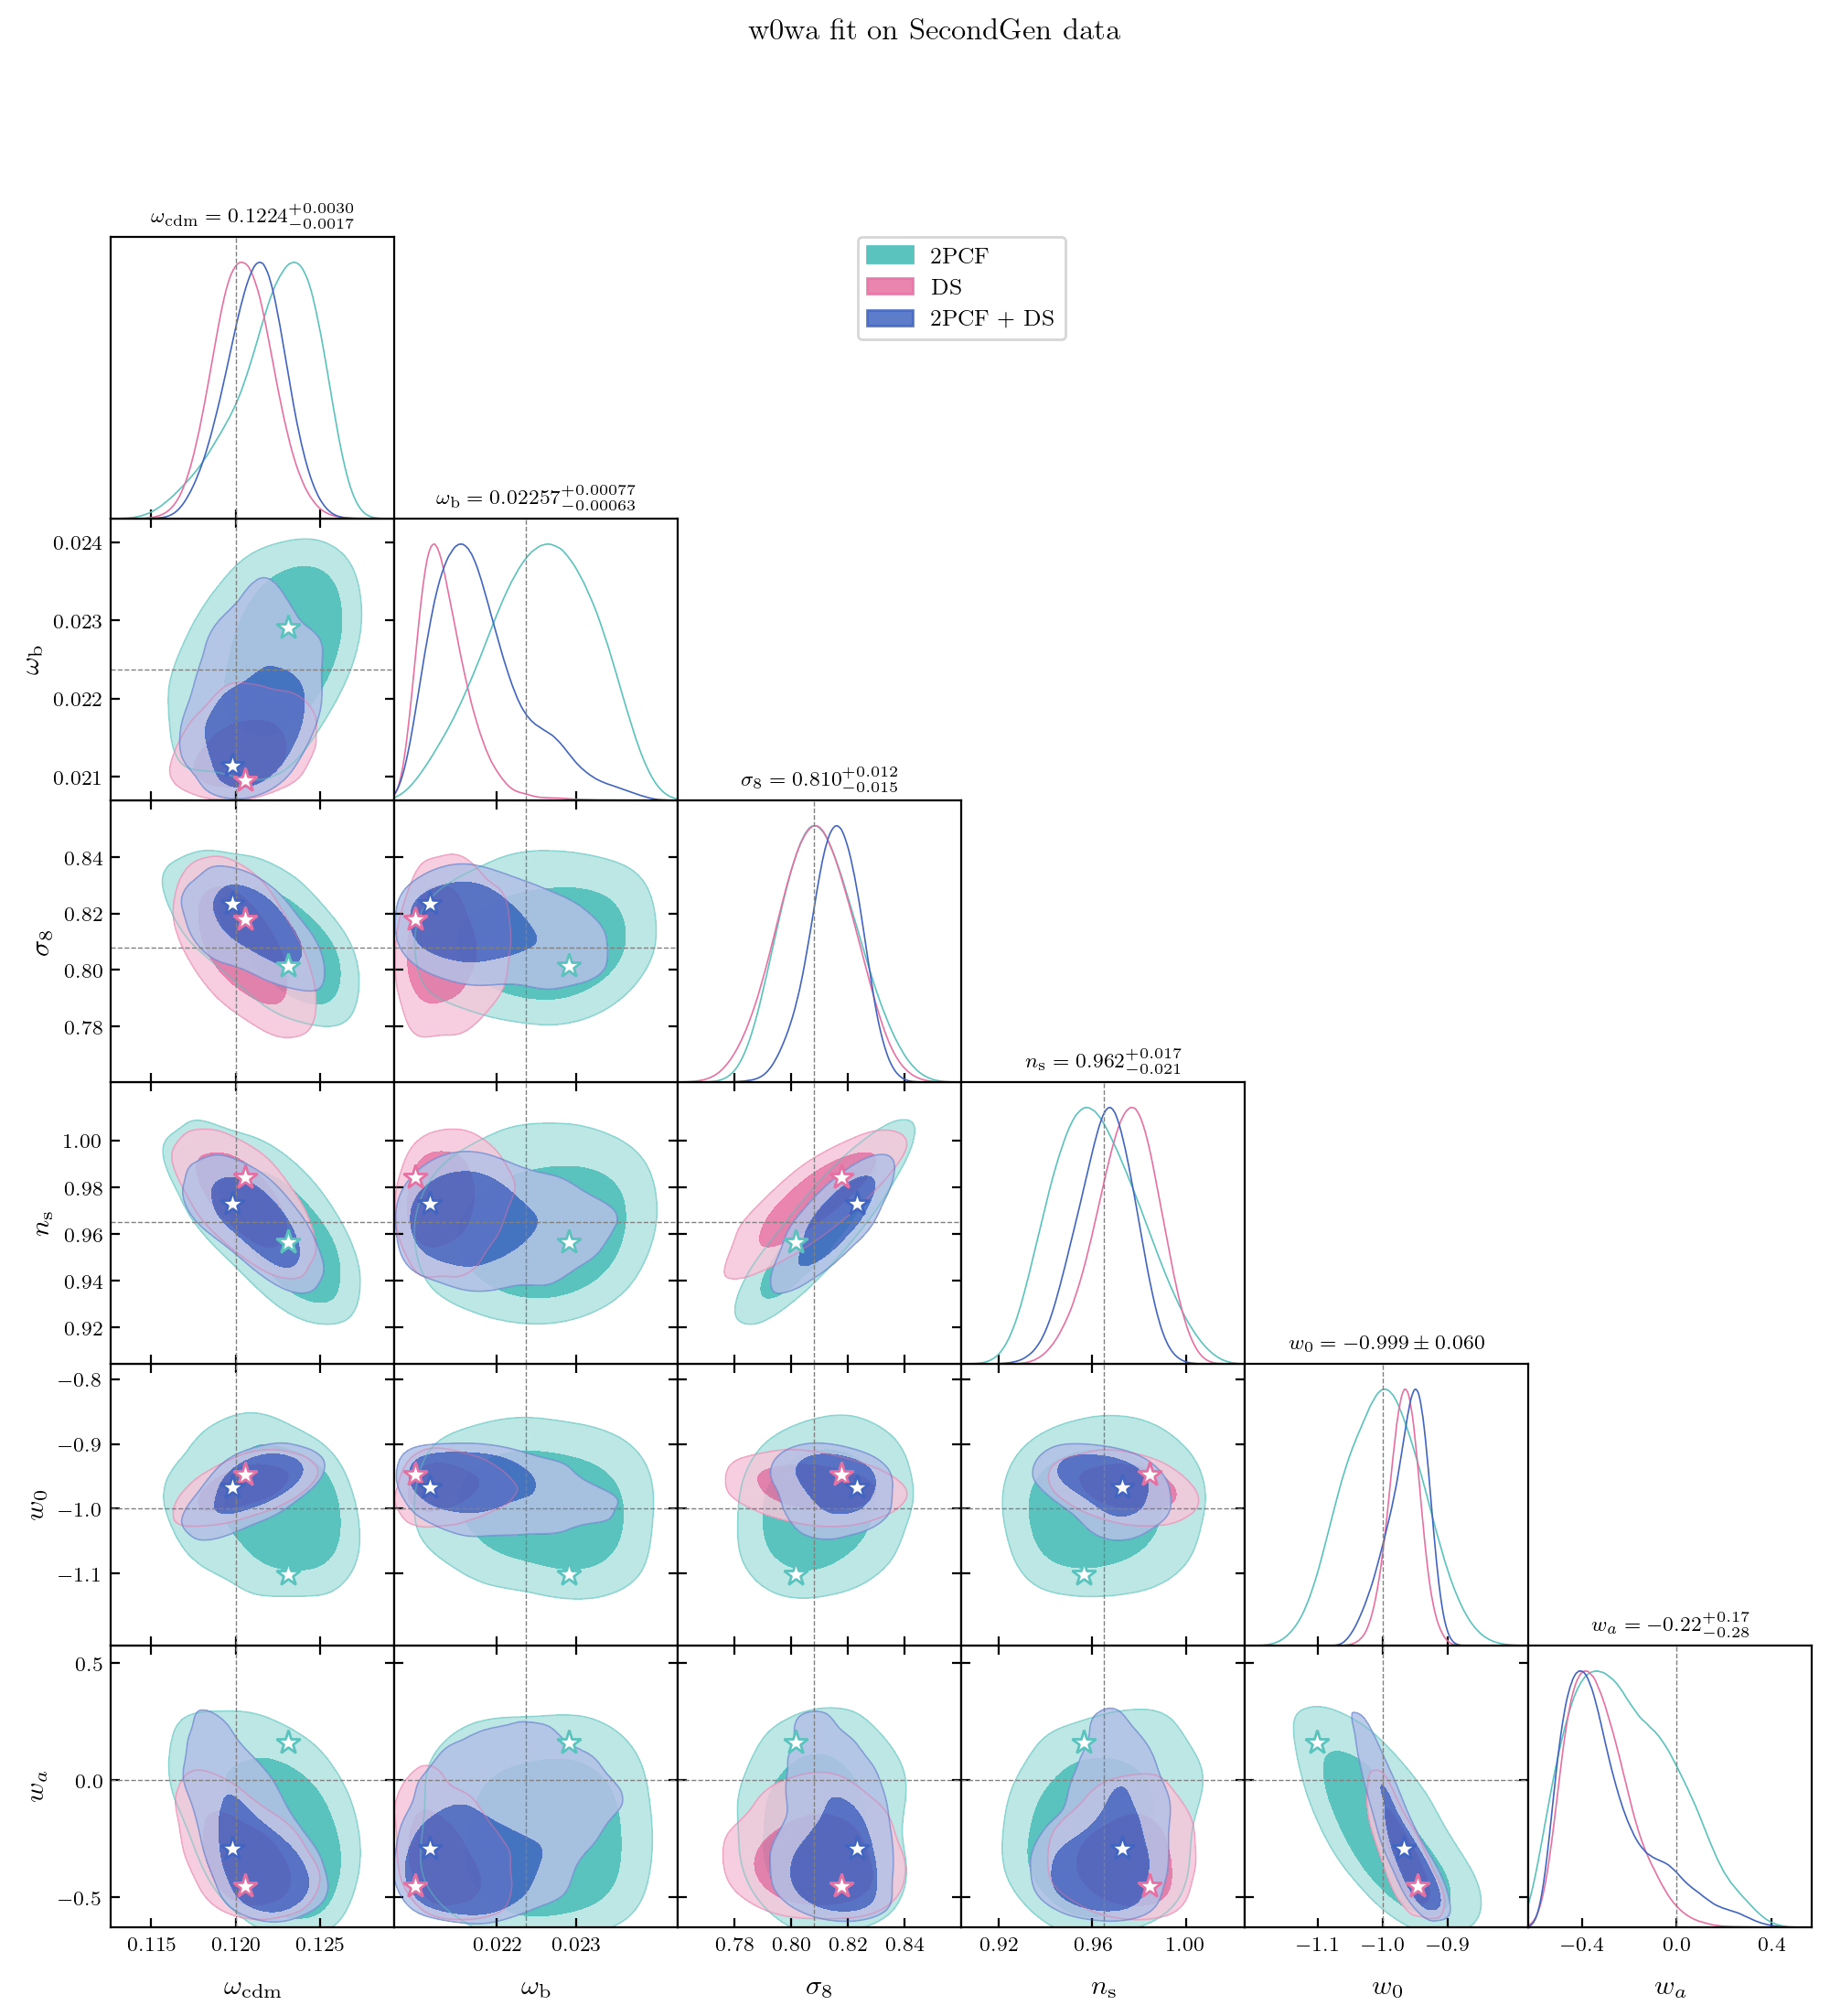

In [111]:
chains = get_chains(type_fit='secondgen', cosmo_model='base-w0wa', hod_model='base-AB-CB-VB-s')

markers = chains[0].markers
chains[0].plot_triangle(*chains[1:], add_bestfit=True, colors=colors, filled=True, title_limit=1, label_dict=label_dict, markers=markers, params=cosmo_params);

fig = plt.gcf()
fig.suptitle('w0wa fit on SecondGen data');

# Model prediction vs truth for SecondGen

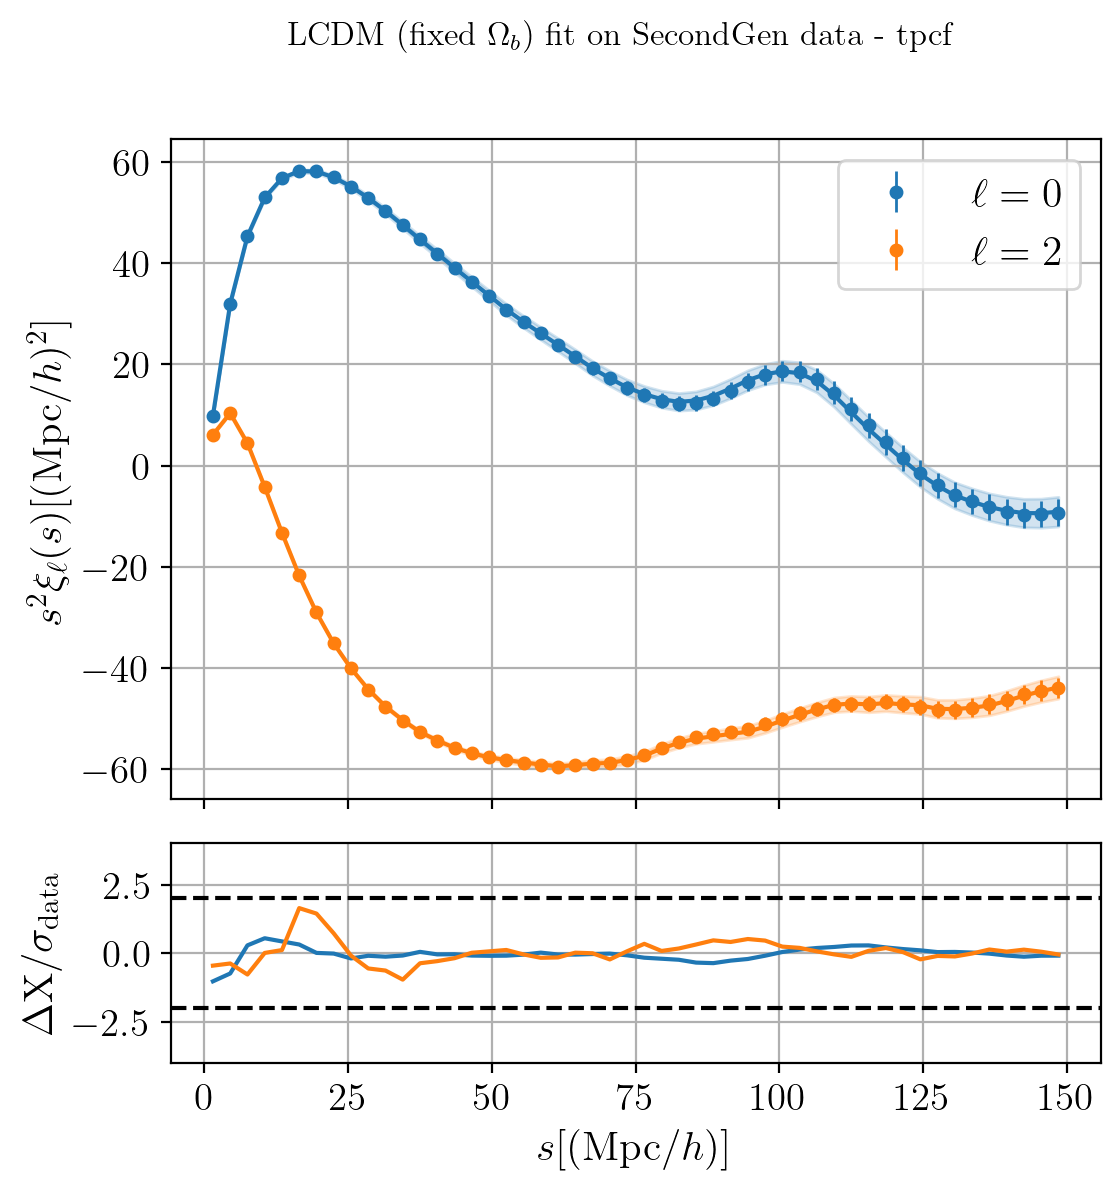

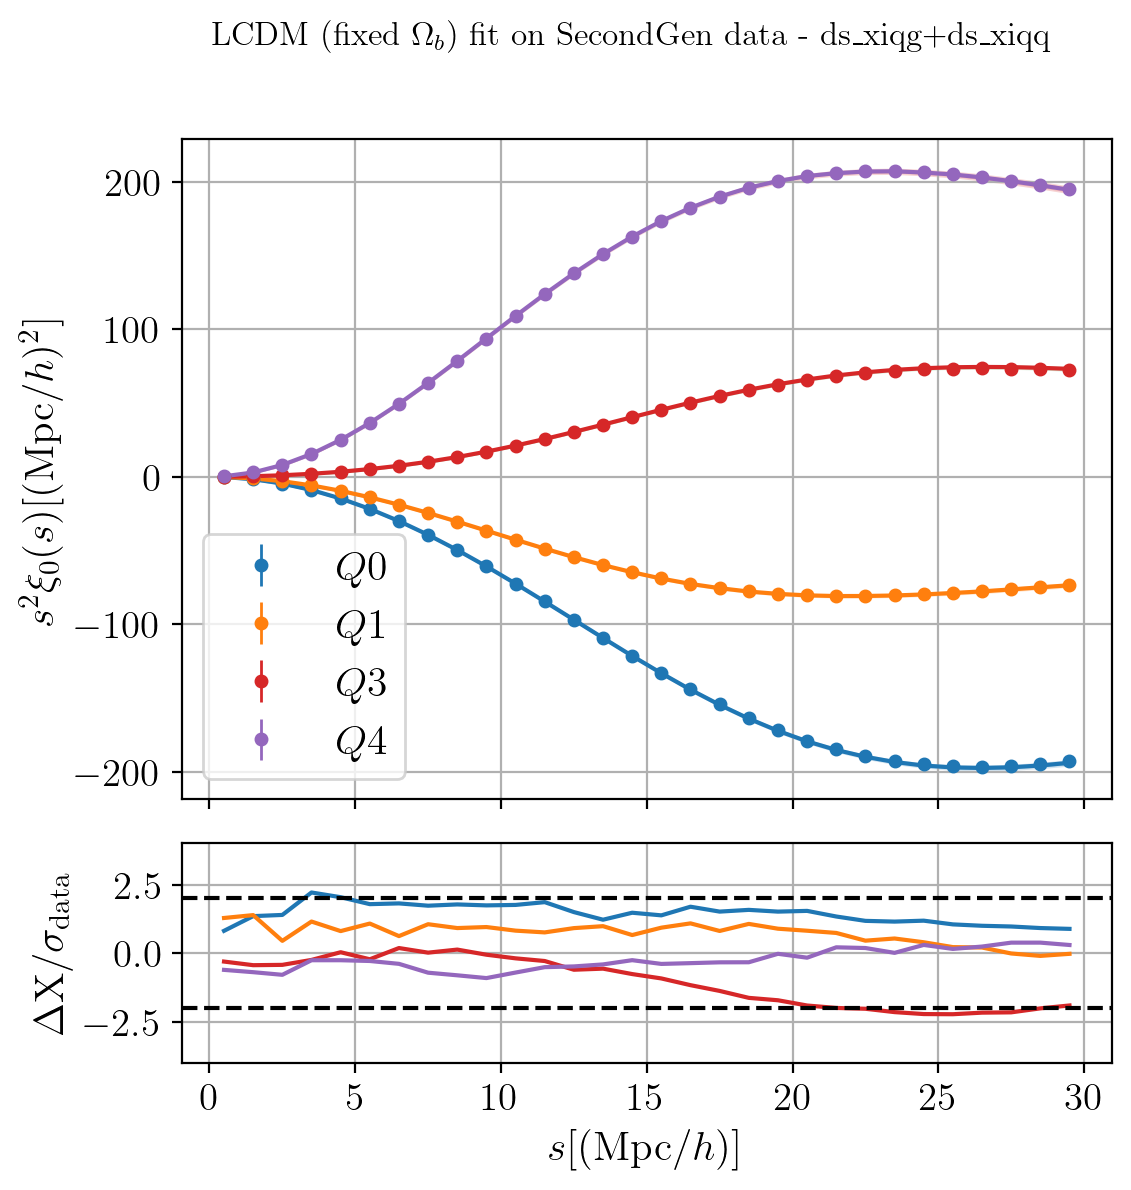

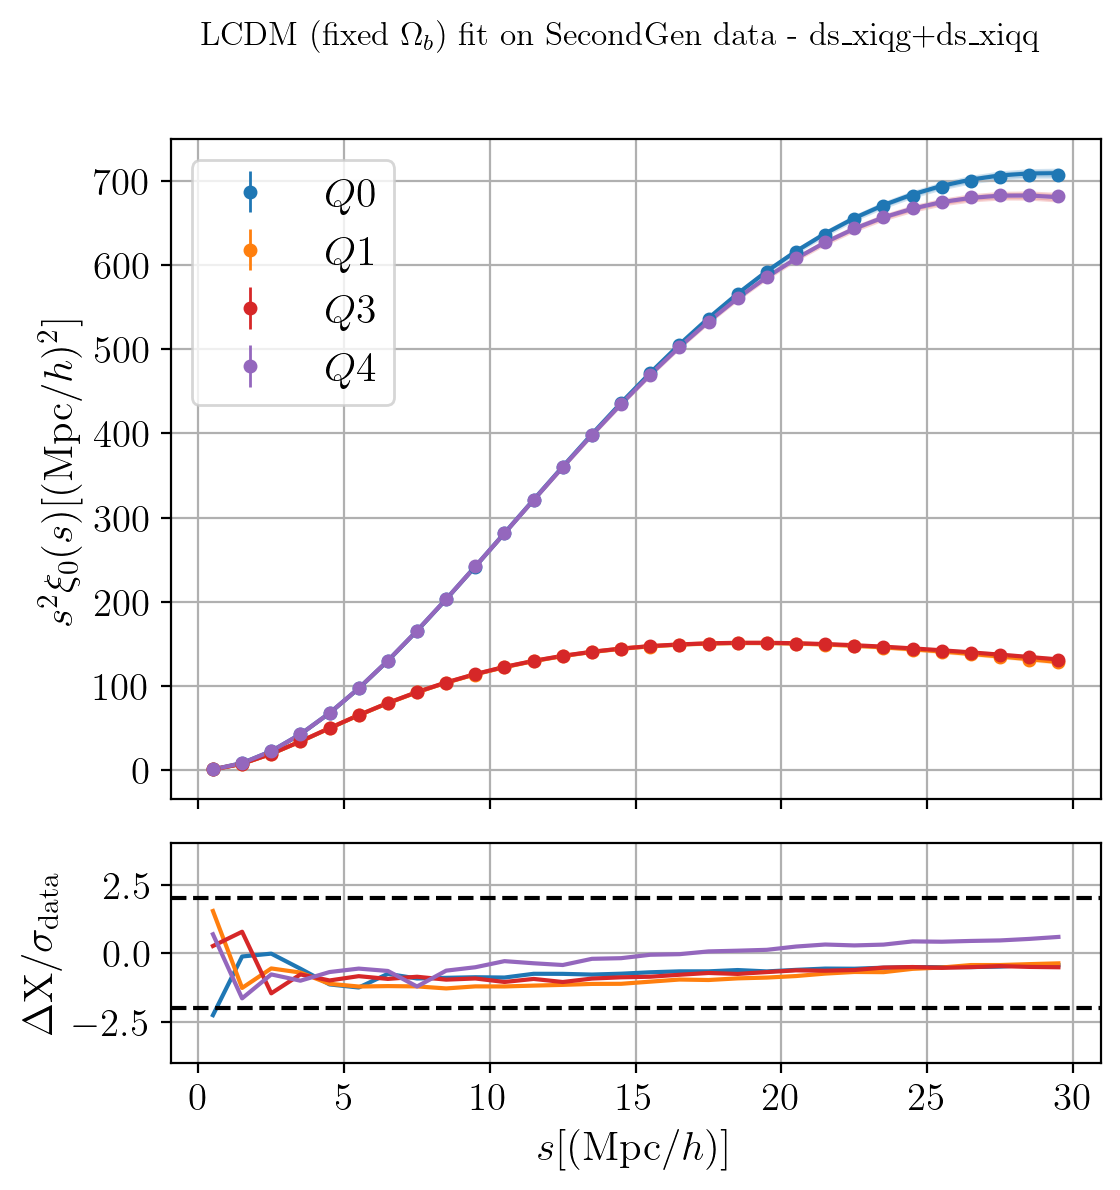

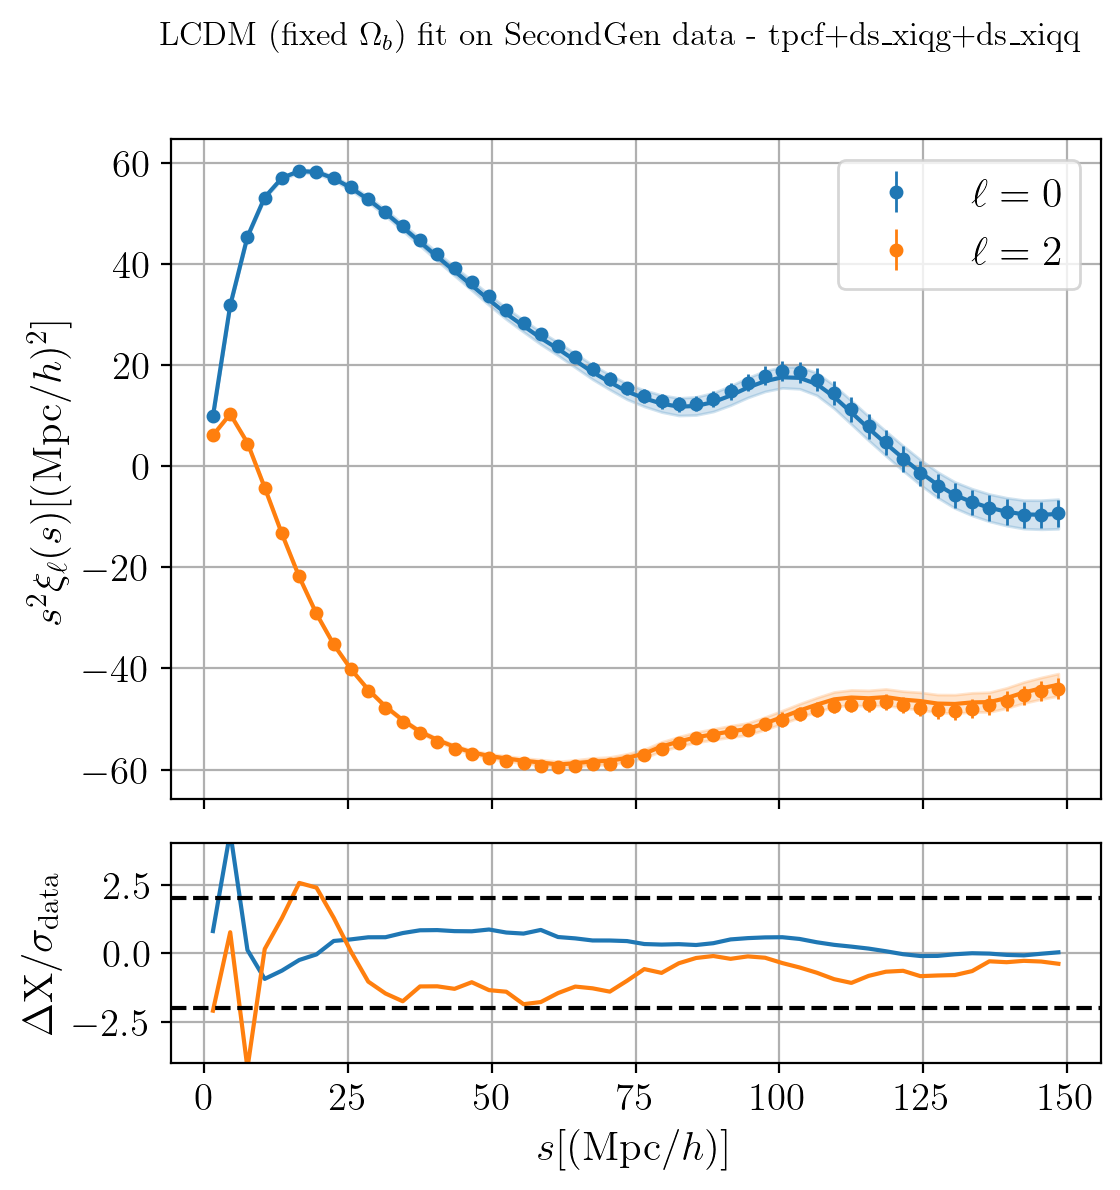

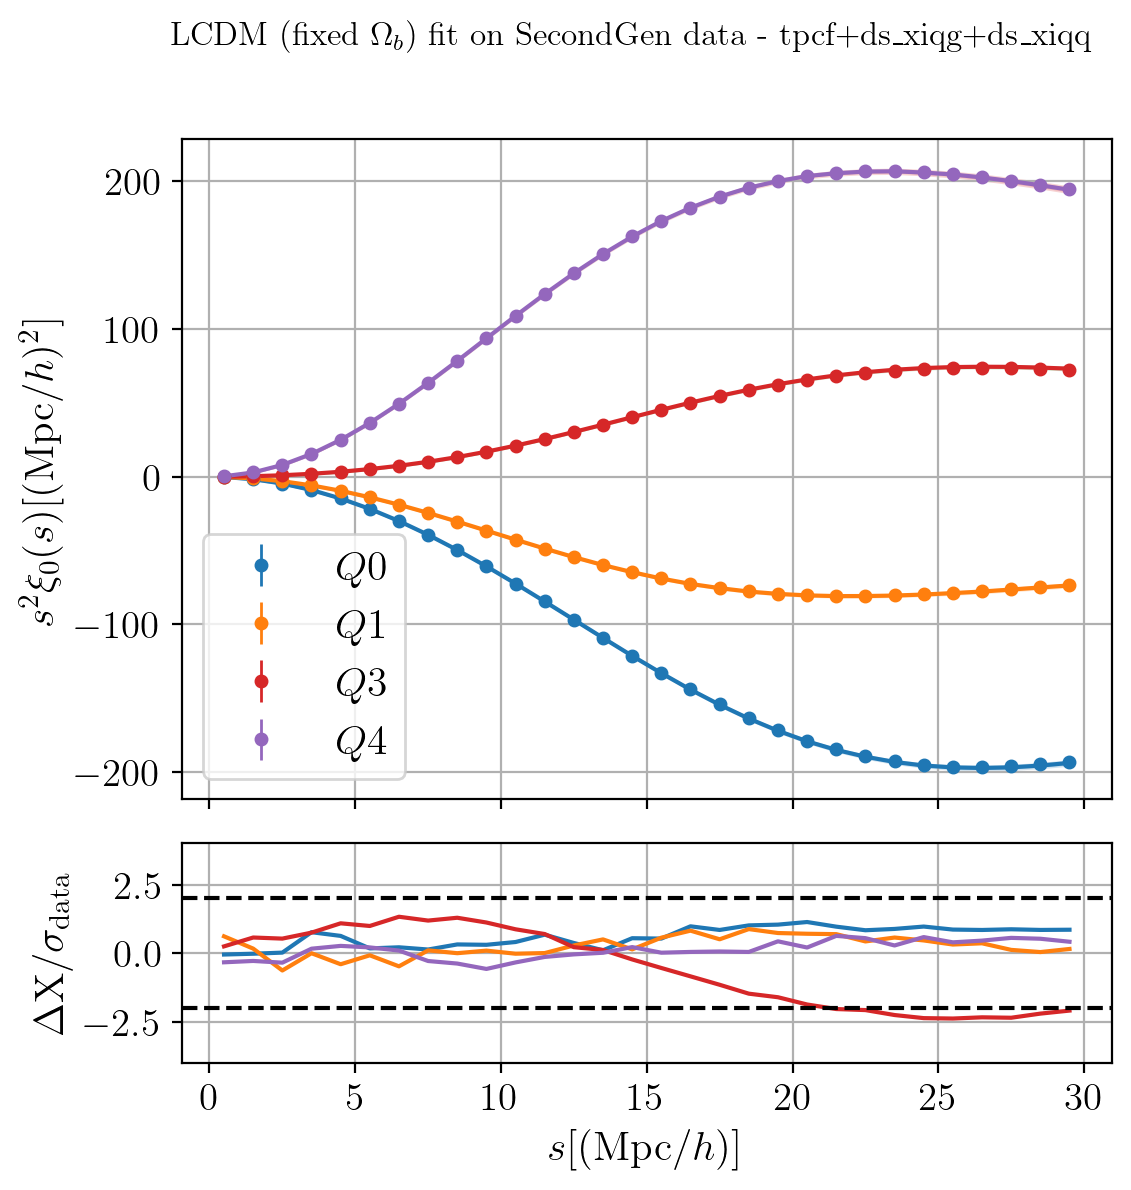

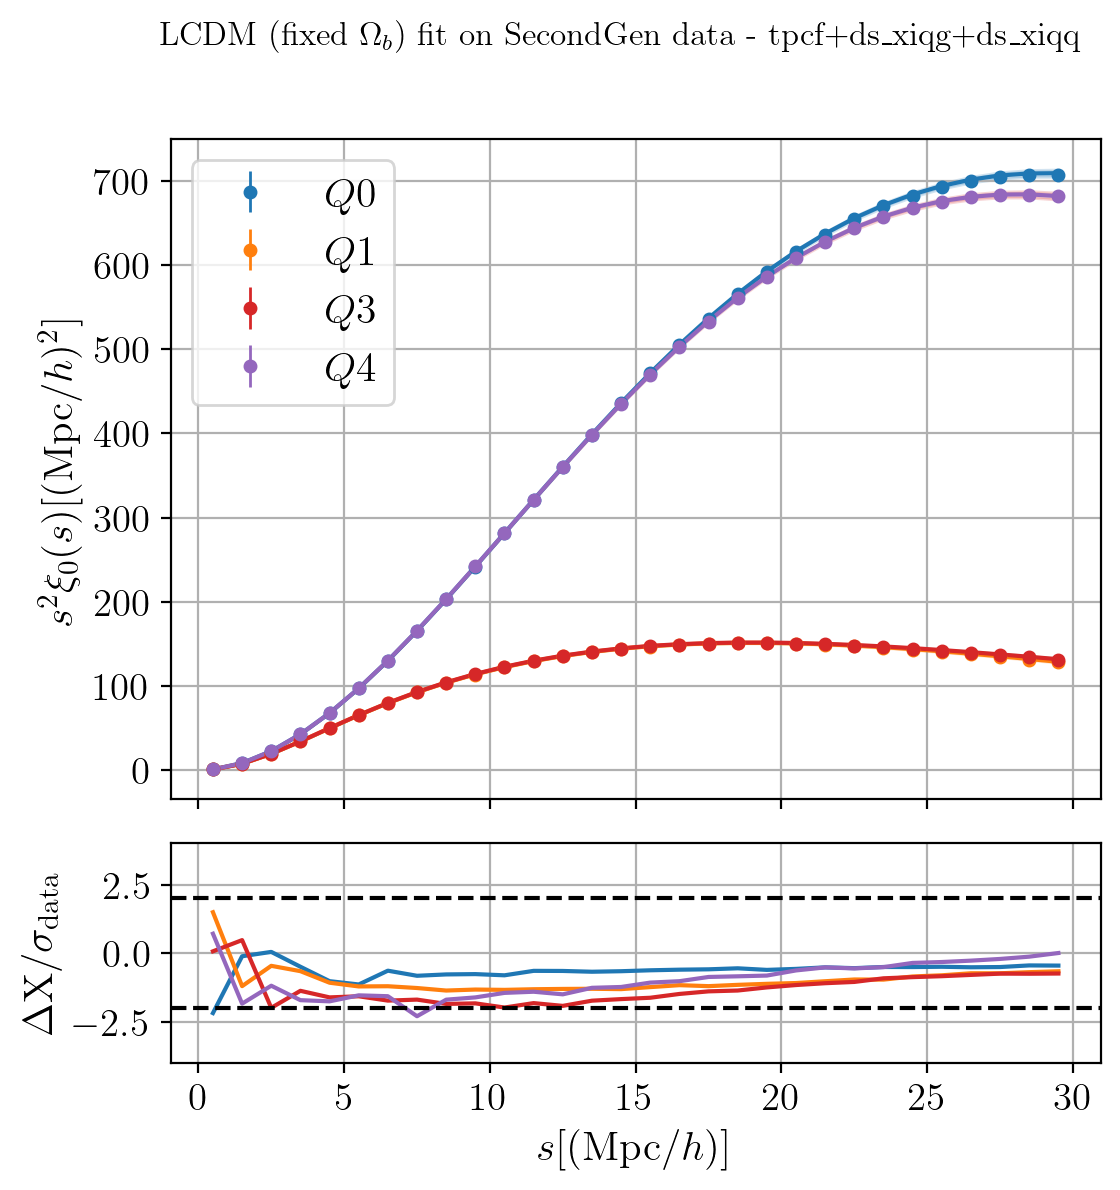

In [11]:
chains = get_chains(type_fit='secondgen', cosmo_model='base-fixed-omega_b', hod_model='base-AB-CB-VB-s')

for chain in chains:
    label = chain.data['label']
    stats = label.split('+')
    for stat in stats:
        fig, ax = plot_secondgen_model_vs_truth(chain, observable_name=stat)
        fig.suptitle(rf'LCDM (fixed $\Omega_b$) fit on SecondGen data - {label}');

## Old tests

### First plot testing the secondgen inference 

/global/u1/s/sbouchar/acm-repo/acm/observables/combined.py:230: UserWarning: combined data covariance matrix is ill-conditioned. This may lead to unreliable results when inverting the matrix in likelihood analysis. Using the diagonal covariance only may be a temporary workaround.
  check_covariance_matrix(cov, name="combined data covariance")
/global/u1/s/sbouchar/acm-repo/acm/observables/combined.py:230: UserWarning: combined data covariance matrix is not positive-definite. Found 15 negative eigenvalue(s), minimum eigenvalue: -1.759073e-24. This will cause issues when inverting the matrix in likelihood analysis. Consider checking the mock realizations or increasing the number of samples.
  check_covariance_matrix(cov, name="combined data covariance")
/global/u1/s/sbouchar/acm-repo/acm/observables/combined.py:230: UserWarning: combined data covariance matrix is singular (ill-conditioned). This will cause issues when inverting the matrix in likelihood analysis. Using the diagonal covari

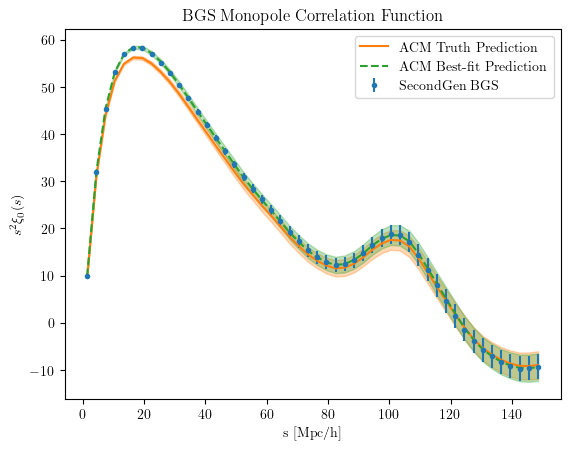

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sunbird.inference.samples import Chain
from acm.observables.bgs import tpcf
from secondgen_bgs import get_secondgen_data

obs = tpcf(select_filters=dict(ells=0), numpy_output=True)
s = obs.s

sg_tpcf = get_secondgen_data(obs, return_obs=True)
truth = sg_tpcf.y
sg_err = np.sqrt(np.diag(sg_tpcf.get_covariance_matrix(volume_factor=1.0)))

pred = obs.get_model_prediction(sg_tpcf.x)

model_err = obs.get_emulator_error()
mock_err = np.sqrt(np.diag(obs.get_covariance_matrix()))
pred_err = np.sqrt(model_err**2 + mock_err**2)

chain = Chain.load('/pscratch/sd/s/sbouchar/acm/bgs-20/chains/secondgen/cosmo-base_hod-base-VB-AB-CB-s/tpcf.npy')

pred_fit = obs.get_model_prediction(chain.bestfit)

plt.errorbar(s, truth*s**2, yerr=sg_err*s**2, fmt='o', ms=3, label='SecondGen BGS')

plt.plot(s, pred*s**2, label='ACM Truth Prediction')
plt.fill_between(s, (pred - pred_err)*s**2, (pred + pred_err)*s**2, color='C1', alpha=0.3)

plt.plot(s, pred_fit*s**2, label='ACM Best-fit Prediction', linestyle='--')
plt.fill_between(s, (pred_fit - pred_err)*s**2, (pred_fit + pred_err)*s**2, color='C2', alpha=0.3)

plt.xlabel('s [Mpc/h]')
plt.ylabel(r'$s^2 \xi_0(s)$')
plt.title('BGS Monopole Correlation Function')
plt.legend();

### Plot examples

Removed no burn in
Removed no burn in


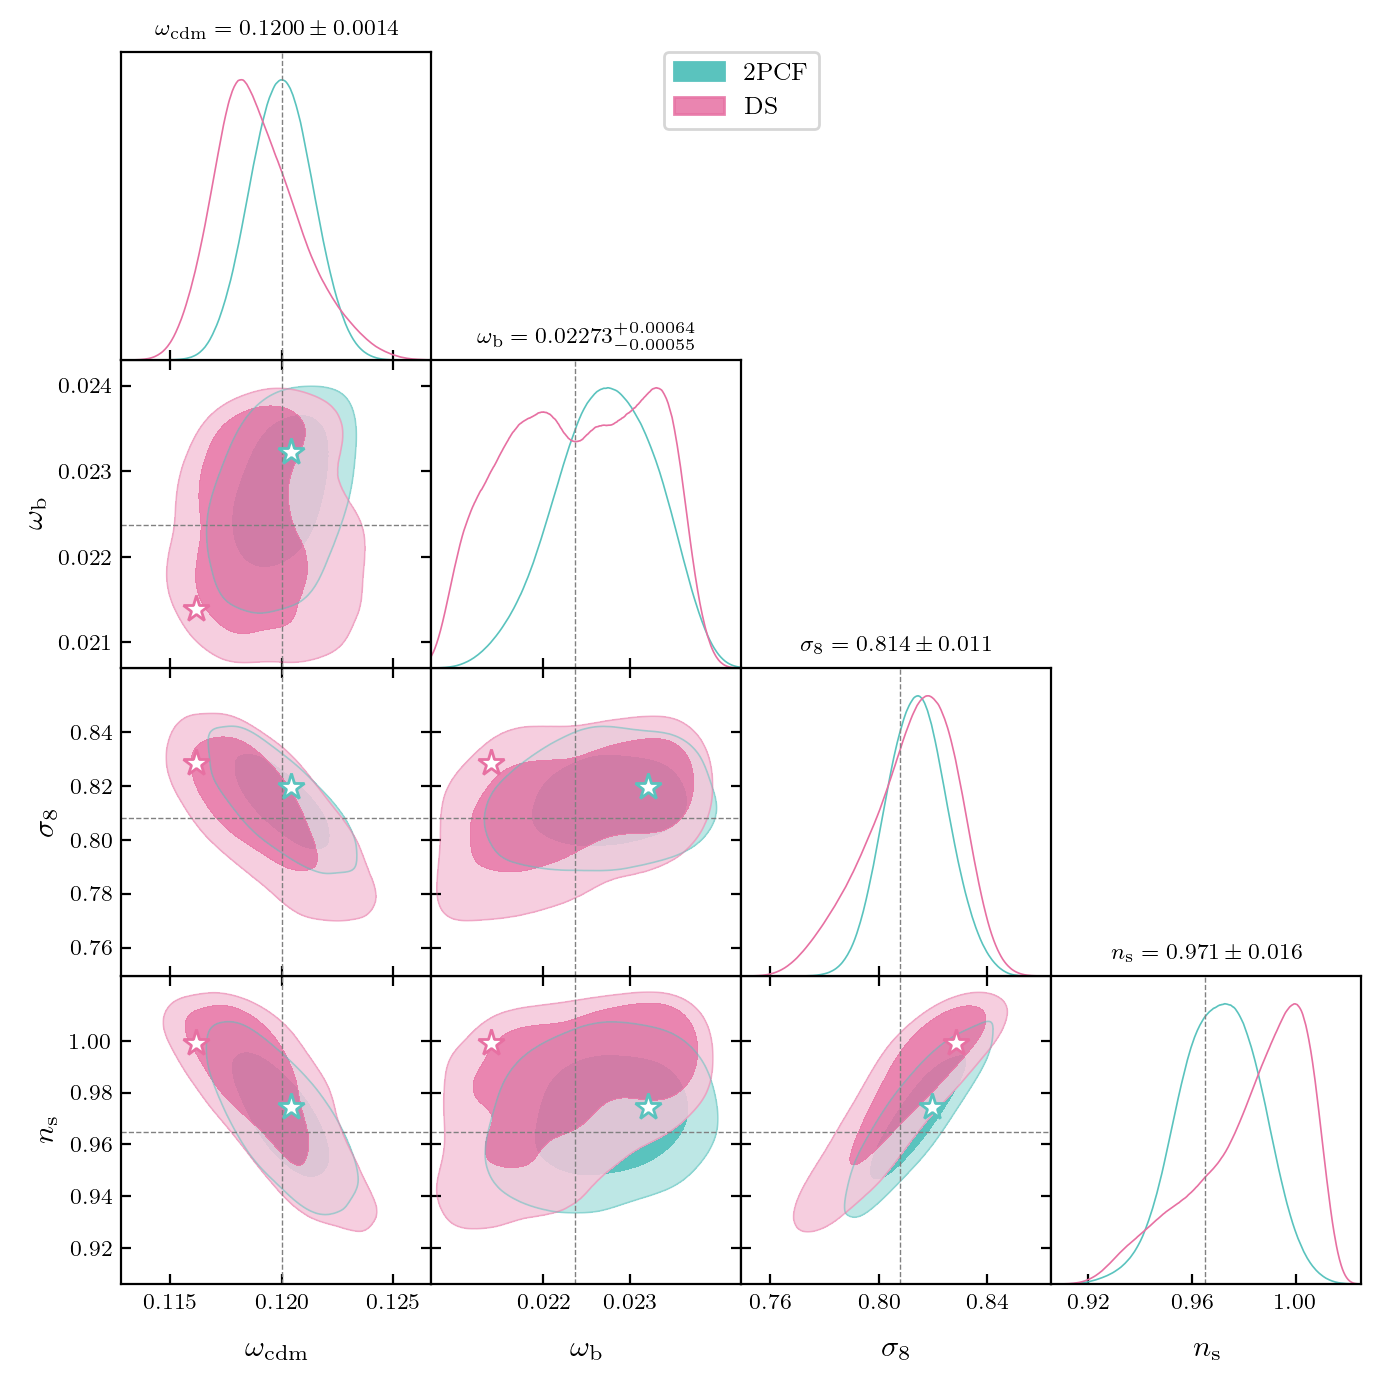

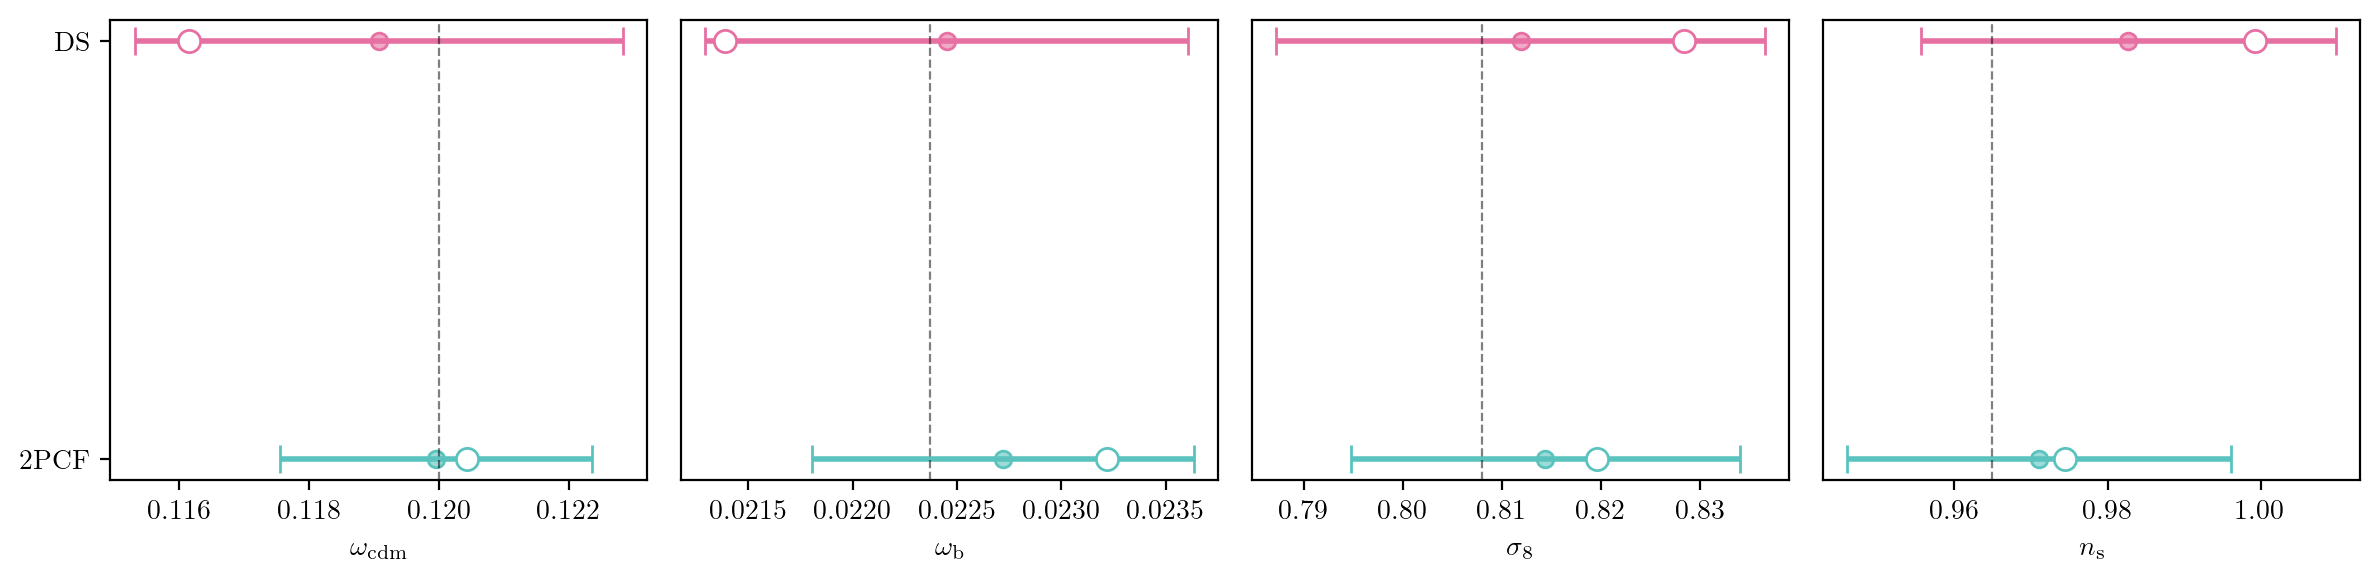

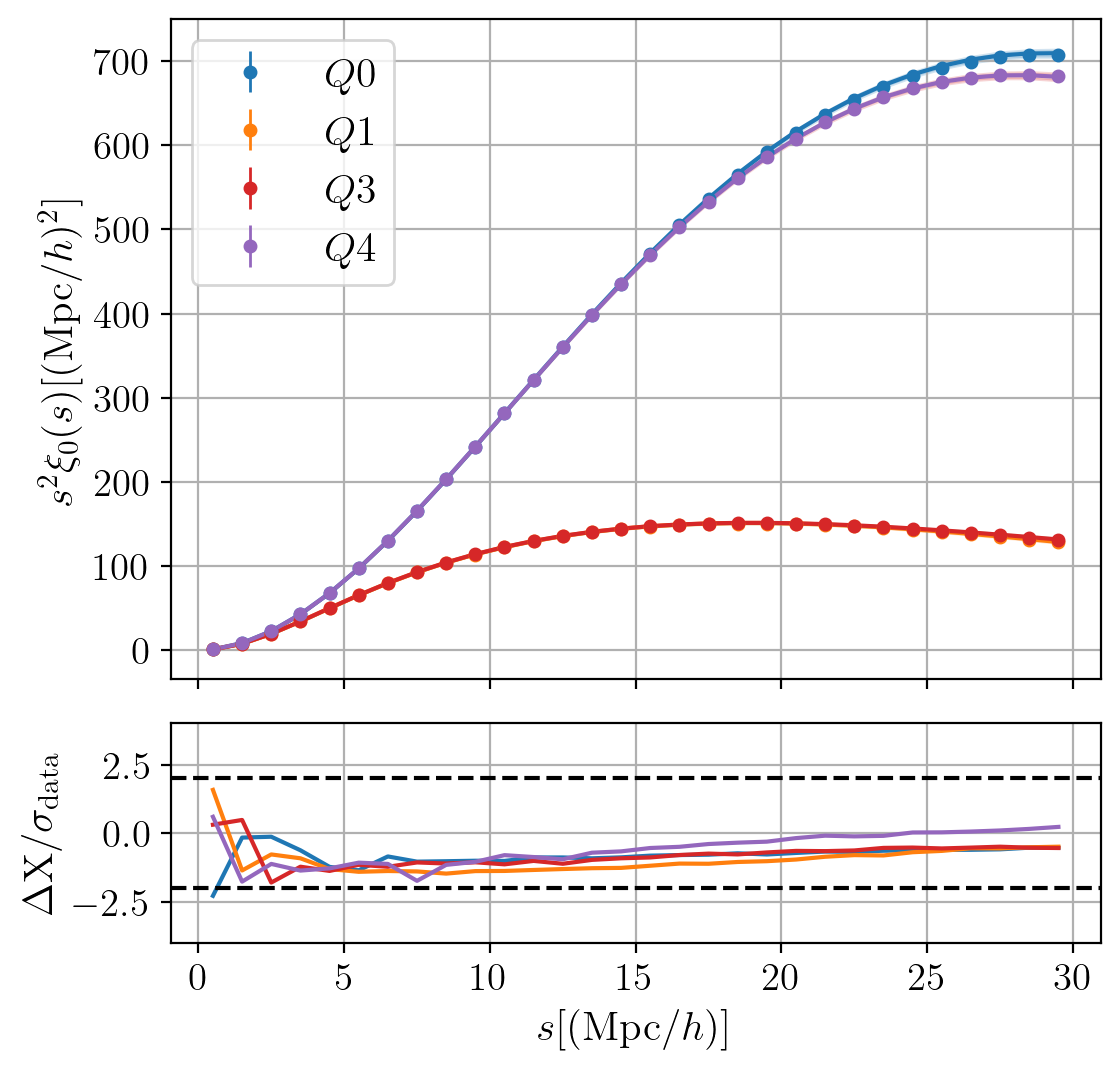

In [ ]:
# SecondGen LCDM w/ Full HOD
type_fit = 'secondgen'
cosmo_model = 'base'
hod_model = 'base-VB-AB-CB-s'

# Triange plot
chains = get_chains(type_fit, cosmo_model, hod_model)
markers = chains[0].markers
chains[0].plot_triangle(*chains[1:], add_bestfit=True, colors=colors, filled=True, title_limit=1, label_dict=label_dict, markers=markers, params=cosmo_params)

# MAP
chains[0].plot_map(*chains[1:], colors=colors, label_dict=label_dict, markers=markers, params=cosmo_params);

# Model vs Truth plot
fig, ax = plot_secondgen_model_vs_truth(chains[1], observable_name='ds_xiqq')